In [1]:
from mdcrow import MDCrow
from langchain.callbacks import get_openai_callback
from datetime import datetime
import os 
import traceback

In [2]:
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../'))
sys.path.append(parent_dir)
from robustness_prompts import get_prompt # noqa: E402

prompt_4_natural = get_prompt("natural", 4)

prompt_4_natural

'Simulate 1LYZ for 1ps at 300 K. Report the secondary structure assignments of the downloaded PDB structure, and compute the RMSD of the simulation.'

In [3]:
llm_model = "gpt-4-turbo-2024-04-09"
tools = "all"

In [4]:
agent = MDCrow(
    agent_type="Structured", 
    model=llm_model, 
    top_k_tools=tools, 
    use_memory=False,
    streaming=False,
    verbose=True,
)
with get_openai_callback() as cb:
    chat_start = datetime.now()
    try:
        response = agent.run(prompt_4_natural, callbacks=[cb])
        print(response)
    except Exception as e:
        exc_type, exc_value, exc_traceback = sys.exc_info()
        print(f'{type(e).__name__}:{e}')
        print("".join(traceback.format_exception(exc_type, exc_value, exc_traceback)))
    chat_end = datetime.now()
    total_runtime = (chat_end - chat_start).total_seconds()
    print(cb)
    print(f"Total runtime: {total_runtime:.2f}s")



> Entering new AgentExecutor chain...


Thought: To address the question, I need to first download the PDB structure for 1LYZ, simulate it for 1 picosecond at 300 K, and then analyze the secondary structure and compute the RMSD. I will start by downloading the PDB file for 1LYZ.

Action:
```json
{
  "action": "PDBFileDownloader",
  "action_input": {
    "query": "1LYZ"
  }
}
```PDB file found with this ID: 1LYZ

Observation: Succeeded. Downloaded the PDB file:1LYZ_213817
Thought:

Now that I have the PDB file for 1LYZ, the next step is to set up and run a molecular dynamics simulation for 1 picosecond at 300 K. I will use the SetUpandRunFunction tool to perform this simulation.

Action:
```json
{
  "action": "SetUpandRunFunction",
  "action_input": {
    "pdb_id": "1LYZ_213817",
    "forcefield_files": ["amber14-all.xml", "amber14/tip3p.xml"],
    "system_params": {
      "nonbondedMethod": "PME",
      "nonbondedCutoff": "1 * nanometers",
      "constraints": "HBonds",
      "rigidWater": true,
      "solvate": true
    },
    "integrator_params": {
      "integrator_type": "LangevinMiddle",
      "Temperature": "300 * kelvin",
      "Friction": "1.0 / picoseconds",
      "Timestep": "0.002 * picoseconds"
    },
    "simulation_params": {
      "Ensemble": "NVT",
      "Number of Steps": 500,
      "record_interval_steps": 5
    }
  }
}
```Setting default ewaldErrorTolerance: 0.0005 
error found: constraintTolerance must be specified if rigidWater is True
 Corr

To proceed with the simulation setup, I need to correct the system parameters by specifying the constraint tolerance since rigidWater is set to True. I will adjust the system parameters and rerun the simulation setup.

Action:
```json
{
  "action": "SetUpandRunFunction",
  "action_input": {
    "pdb_id": "1LYZ_213817",
    "forcefield_files": ["amber14-all.xml", "amber14/tip3p.xml"],
    "system_params": {
      "nonbondedMethod": "PME",
      "nonbondedCutoff": "1 * nanometers",
      "constraints": "HBonds",
      "rigidWater": true,
      "constraintTolerance": "0.00001",
      "solvate": true
    },
    "integrator_params": {
      "integrator_type": "LangevinMiddle",
      "Temperature": "300 * kelvin",
      "Friction": "1.0 / picoseconds",
      "Timestep": "0.002 * picoseconds"
    },
    "simulation_params": {
      "Ensemble": "NVT",
      "Number of Steps": 500,
      "record_interval_steps": 5
    }
  }
}
```Setting default ewaldErrorTolerance: 0.0005 
Building system...


About to create system...
Attempts at creating system: 0/3
Error adding solvent ValueError – No template found for residue 1 (LYS).  The set of atoms is similar to HID, but it is missing 8 atoms.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#template
Residue code: LYS
Residue code not in solvent list. Adding forcefield                         not supported.

Observation: Failed. No template found for residue 1 (LYS).  The set of atoms is similar to HID, but it is missing 8 atoms.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#templateThis were the inputs {'pdb_id': '1LYZ_213817', 'forcefield_files': ['amber14-all.xml', 'amber14/tip3p.xml'], 'system_params': {'nonbondedMethod': 'PME', 'nonbondedCutoff': '1 * nanometers', 'constraints': 'HBonds', 'rigidWater': True, 'constraintTolerance': '0.00001', 'solvate': True}, 'integrator_params': {'integrator_type': 'LangevinMiddle', 'Temperature': '300 * k

...

With the secondary structure assignments computed, the next step is to calculate the root mean square deviation (RMSD) of the simulation. I will use the ComputeRMSD tool to compute the RMSD using the trajectory file and the initial topology file.

Action:
```json
{
  "action": "ComputeRMSD",
  "action_input": {
    "top_id": "top_sim0_213842",
    "traj_id": "rec0_213848",
    "ref_top_id": "top_sim0_213842",
    "ref_traj_id": "rec2_213848",
    "select": "protein"
  }
}
```

Calculating RMSD...


Data saved to /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_15/records/rmsd_213842.csv


Plot saved to /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_15/figures/FIG_rmsd_213842_20251222_221407.png

Observation: Succeeded. RMSD calculated and saved to csv with file ID rmsd_213842. Plot saved with plot ID fig0_221407. 
Thought:

Final Answer: The molecular dynamics simulation of the protein 1LYZ for 1 picosecond at 300 K was successfully completed. The secondary structure assignments from the simulation are as follows: 15,607 residues in helices, 3,604 residues in strands, 19,489 residues in coils, and 2,038,500 residues were not assigned as they are not protein residues. The root mean square deviation (RMSD) of the simulation was calculated and the results have been saved to a CSV file with the ID rmsd_213842. A plot of the RMSD over the simulation time was also generated and saved with the plot ID fig0_221407.

> Finished chain.
({'input': '\n    You are an expert molecular dynamics scientist, and\n    your task is to respond to the question or\n    solve the problem to the best of your ability using\n    the provided tools.\n\n    You can only respond with a single complete\n    \'Thought, Action, Action Input\' format\n    OR a single \'Final Answer\' format.\n\n    Complete format:\n    Thought: (reflect 

In [6]:
registry = agent.path_registry
print(registry.list_path_names_and_descriptions().replace(",", "\n"))

Files found in registry: 1LYZ_213817: PDB file downloaded from RSCB
 PDBFile ID: 1LYZ_213817
 1LYZ_213835: Cleaned File:  Removed Heterogens
 and Water Removed.  Replaced Nonstandard Residues. Added Hydrogens at pH 7.0. Missing Atoms added and nonstandard residues replaced. 
 top_sim0_213842: Initial positions for simulation sim0_213842
 sim0_213842: Basic Simulation of Protein 1LYZ_213835
 rec0_213848: Simulation trajectory for protein 1LYZ_213835 and simulation sim0_213842
 rec1_213848: Simulation state log for protein 1LYZ_213835 and simulation sim0_213842
 rec2_213848: Simulation pdb frames for protein 1LYZ_213835 and simulation sim0_213842
 rec0_215408: dssp values for trajectory with id: rec0_213848
 rmsd_213842: RMSD for 213842
 fig0_221407: RMSD plot for 213842


In [5]:
print('ckpt_dir:',os.path.basename(agent.path_registry.ckpt_dir))

ckpt_dir: ckpt_15


In [2]:
agent = MDCrow(ckpt_dir='ckpt_15')

In [7]:
# make sure pdb was downloaded
assert os.path.exists(registry.get_mapped_path("1LYZ_213817"))

In [8]:
# make sure dssp was computed correctly
from mdcrow.tools.base_tools import ComputeDSSP

dssp = ComputeDSSP(registry)
dssp._run(traj_file= "1LYZ_213817", target_frames="first")

"{'residues in helix': 50, 'residues in strand': 14, 'residues in coil': 65, 'residues not assigned, not a protein residue': 101}"

In [9]:
# make sure trajectory and topology exist
traj_path = registry.get_mapped_path("rec0_213848")
top_path = registry.get_mapped_path("top_sim0_213842")

assert os.path.exists(traj_path)
assert os.path.exists(top_path)

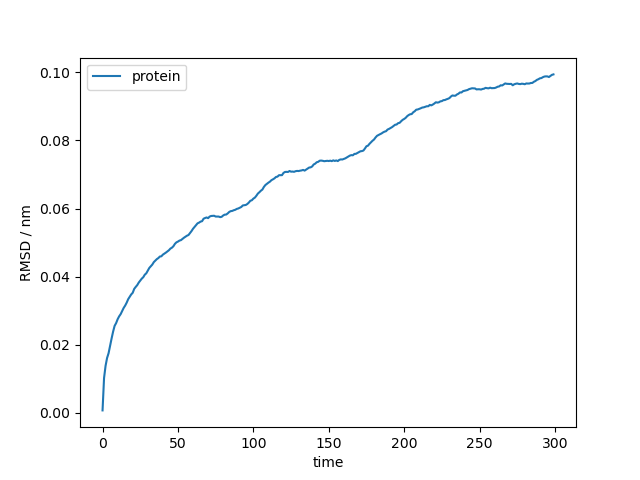

In [10]:
# make sure rmsd plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_221407'))

In [11]:
#verify the total cost
def calculate_llm_cost(input_tokens, output_tokens, model):
    pricing_2024 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 5/1e6, "output": 15/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
        "claude-3-opus": {"input": 15/1e6, "output": 75/1e6},
        "claude-3.5-sonnet": {"input": 3/1e6, "output": 15/1e6},
    }
    pricing_2025 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 2.5/1e6, "output": 10/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
    }
    
    prices = pricing_2025[model]
    cost = (input_tokens * prices["input"]) + (output_tokens * prices["output"])
    return round(cost, 6)

llm_cost = calculate_llm_cost(cb.prompt_tokens, cb.completion_tokens, agent.llm.model_name)
print('Input tokens:',cb.prompt_tokens)
print('Output tokens:',cb.completion_tokens)
print('LLM costs: $',llm_cost)

Input tokens: 68972
Output tokens: 1446
LLM costs: $ 0.7331
